In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3080 Ti'

In [4]:
from make import load_secondary_data, load_heath_assessment_test_data

all_spectrograms, all_labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [5]:
len(all_labels)

600

In [6]:
len(all_spectrograms)

600

In [7]:
from validation_util import get_label_index

valid_spec, valid_labels = load_heath_assessment_test_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 

In [8]:
len(all_spectrograms)

600

In [9]:
print(f'Initial shape of a spectrogram: ', all_spectrograms[0].shape)

ch, freq_bins = all_spectrograms[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')
print(f'Input Type: {type(all_spectrograms[0])}')


Initial shape of a spectrogram:  (33, 128)
Final shape: (33, 36)
Input Type: <class 'numpy.ndarray'>


In [10]:
# constants you can tweak once
FLOOR_DB   = -45.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [11]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def get_x(i : int):
        arr = all_spectrograms[i]

        if arr.ndim == 3:
                arr = np.mean(arr, axis=-1)  # (H, W)

        # Ensure float32
        arr = arr.astype(np.float32)

        # If not already in dB, convert. If it *is* already in dB, skip this block.
        #arr = np.maximum(arr, EPS)
        #arr_db = 10.0 * np.log10(arr)

        # Apply dynamic range floor and normalize to [0,1]
        arr = arr - arr.max()
        arr = np.clip(arr, FLOOR_DB, 0.0)
        arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

        arr_01 = arr_01.astype(np.float32)

        arr_01 = arr_01 ** 0.9

        arr_01 = np.flipud(arr_01)

        cmap = plt.get_cmap('magma')
        img_rgb = cmap(arr_01)[:, :, :3]


        # Convert to tensor and make 3-channel (grayscale -> RGB-style)
        t = torch.from_numpy(img_rgb)          # (H, W)
        t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

        # Add batch dimension for interpolate
        #t = t.unsqueeze(0)                    # (1, 3, H, W)

        # Resize
        t_resized = F.interpolate(
                t, size=TARGET_HW, mode='bilinear', align_corners=False
        )

        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return all_labels[i]

In [12]:
from plot_util import PlotUtil

plotUtil = PlotUtil(spectrograms=all_spectrograms)

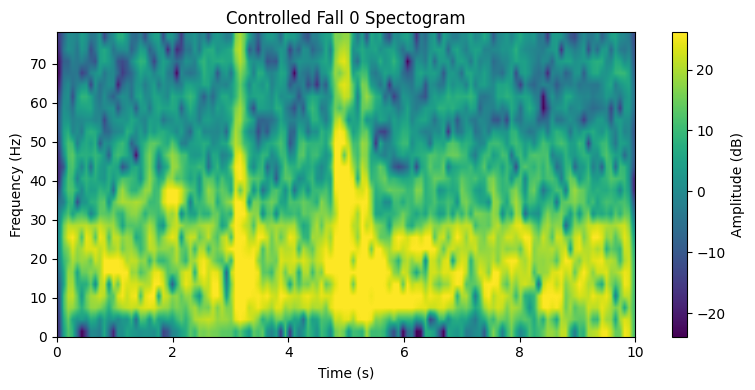

In [13]:
plotUtil.show_spec(get_label_index('Controlled Fall', all_labels), title=f'Controlled Fall {get_label_index('Controlled Fall', all_labels)} Spectogram')

<Axes: >

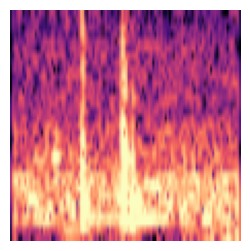

In [14]:
get_x(0).show()

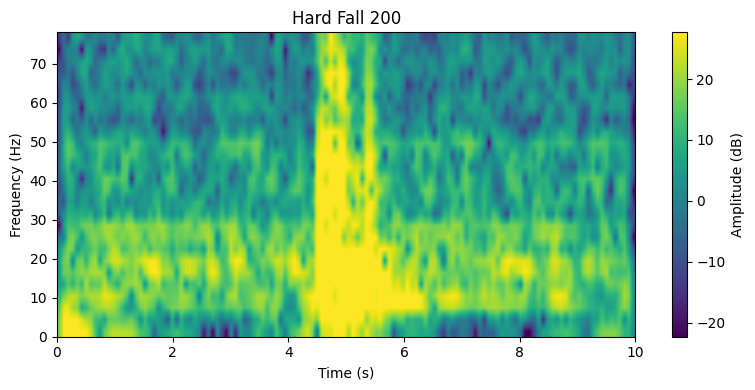

In [15]:
plotUtil.show_spec(get_label_index("Hard Fall", all_labels), title=f'Hard Fall {get_label_index("Hard Fall", all_labels)}')

<Axes: >

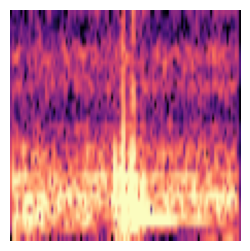

In [16]:
get_x(181).show()

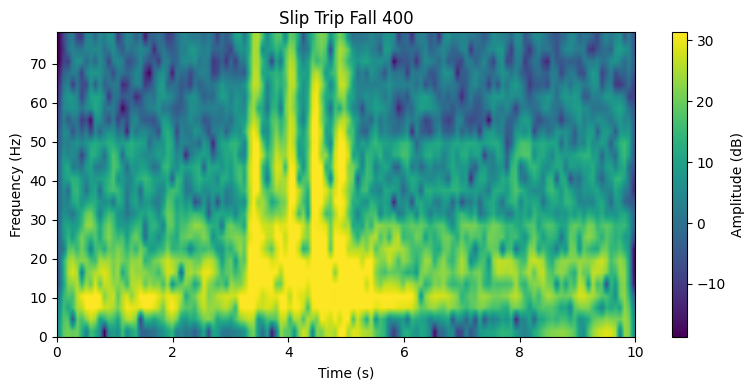

In [17]:
plotUtil.show_spec(get_label_index("SlipTrip", all_labels), title=f'Slip Trip Fall {get_label_index("SlipTrip", all_labels)}')


<Axes: >

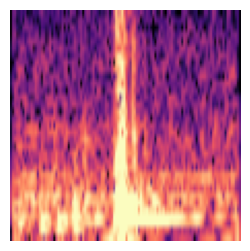

In [18]:
get_x(364).show()

In [19]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [20]:
len(all_labels)

600

In [21]:
items = list(range(len(all_spectrograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

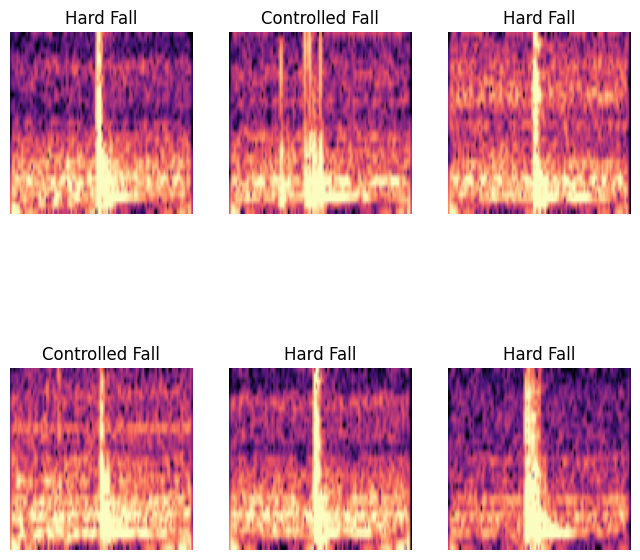

In [22]:
dls.show_batch(max_n=6, figsize=(8,8))

In [23]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

## Only run if you dont have a learner yet! 

In [82]:
learner = vision_learner(dls, xse_resnext34_deeper, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

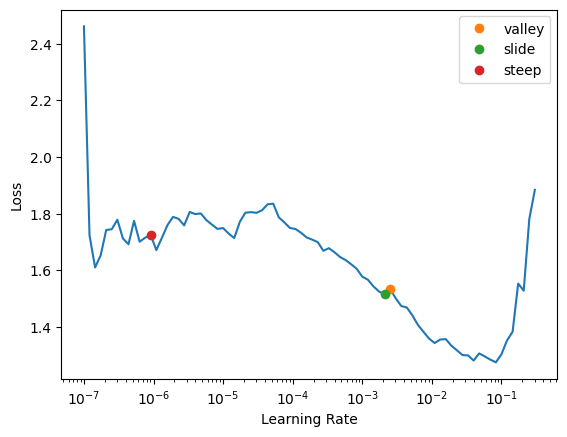

In [83]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [84]:
learner.fine_tune(20)

epoch,train_loss,valid_loss,accuracy,time
0,1.137768,0.559450,0.791667,00:01


epoch,train_loss,valid_loss,accuracy,time
0,0.562972,0.435834,0.833333,00:02
1,0.502026,0.400951,0.833333,00:02
2,0.445449,0.362257,0.866667,00:02
3,0.406212,0.370942,0.858333,00:02
4,0.381378,0.452301,0.825000,00:02
5,0.379627,0.480413,0.833333,00:02
6,0.310887,0.442564,0.858333,00:02
7,0.312049,0.394390,0.850000,00:02
8,0.313869,0.400105,0.866667,00:02
9,0.250313,0.413116,0.841667,00:02


In [85]:
learner.unfreeze()

In [86]:
learner.fit_one_cycle(30, lr.valley)

epoch,train_loss,valid_loss,accuracy,time
0,0.155044,0.382353,0.866667,00:02
1,0.299996,1.230543,0.641667,00:02
2,0.445982,0.599039,0.825000,00:02
3,0.634193,2.680130,0.633333,00:02
4,0.609389,1.849718,0.666667,00:02
5,0.555752,4.948285,0.441667,00:02
6,0.500148,0.591691,0.866667,00:02
7,0.406452,0.961342,0.783333,00:02
8,0.416171,0.417563,0.883333,00:02
9,0.374473,0.594249,0.808333,00:02


In [87]:
learner.summary()

Sequential (Input shape: 12 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     12 x 32 x 56 x 56   
Conv2d                                    864        True      
BatchNorm2d                               64         True      
ReLU                                                           
Conv2d                                    9216       True      
BatchNorm2d                               64         True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 56 x 56   
Conv2d                                    18432      True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 28 x 28   
MaxPool2d                          

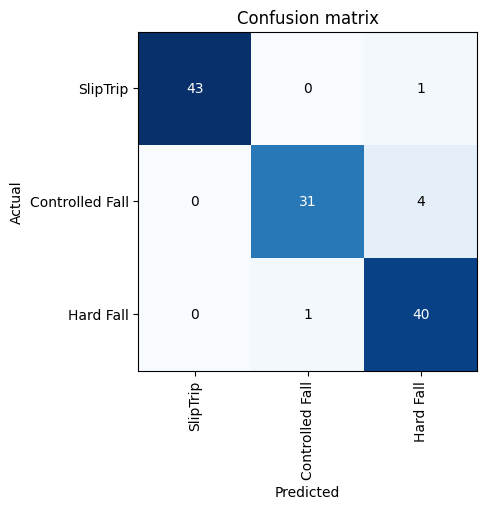

In [88]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [89]:
inter_plot.most_confused()

[('Controlled Fall', 'Hard Fall', np.int64(4)),
 ('SlipTrip', 'Hard Fall', np.int64(1)),
 ('Hard Fall', 'Controlled Fall', np.int64(1))]

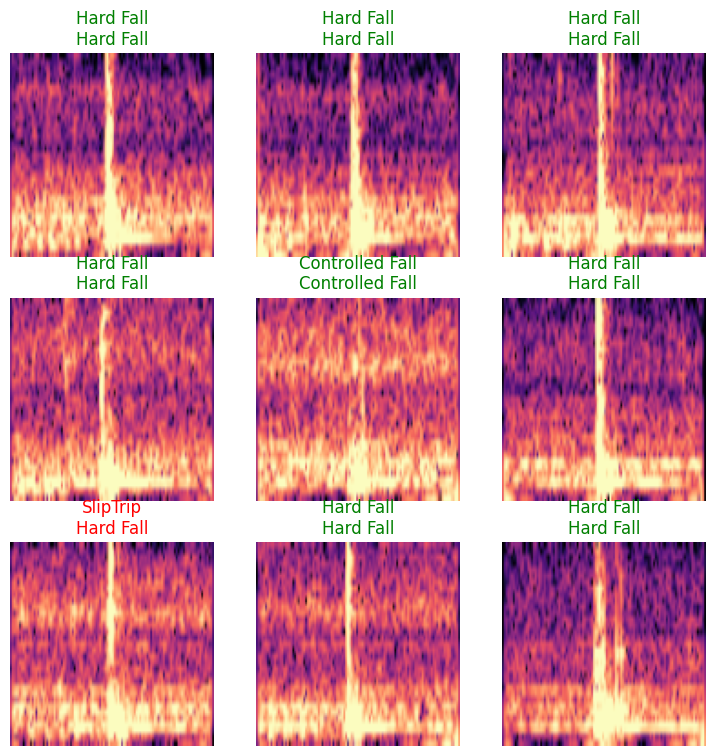

In [90]:
learner.show_results()

In [91]:
has_learned = True

In [92]:
if not has_learned:
    learner = load_learner("./models/ha-model.pkl")
else:
    print("Learner trained, do not load old learner")

Learner trained, do not load old learner


In [93]:
def get_x_test(i):
    arr = valid_spec[i]

    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
            t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [94]:
learner.validate()

(#2) [0.14821641147136688,0.949999988079071]

## Accuracy

This is the relationship between True labes, and all predicted labels. This determens how accurate the model is to predict the true lables. 

$$Accuracy = \frac{TP + TN}{TP + TN + FN + FP} $$

## Precision

The amount of True (or False) labels the model did find belonging to the positive class. The number of True Positives divided by True Positives plus False Positives.  

$$ Precision = \frac{TP}{TP + FP} $$

In [95]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 
    


In [96]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [97]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [98]:
dls.vocab = ["Controlled Fall", "Hard Fall", "SlipTrip"]

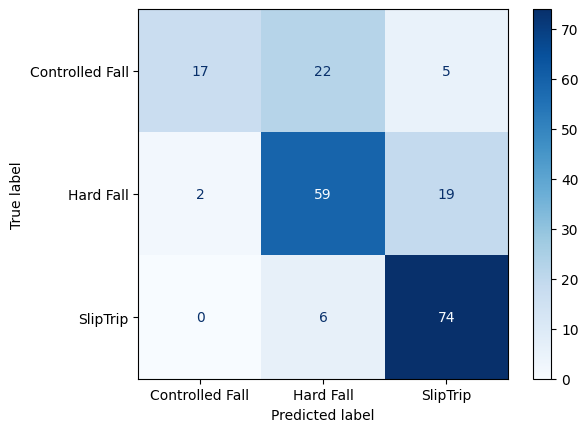

In [99]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [100]:
accuracy_score(y_test, y_pred)

0.7352941176470589

In [101]:
precision_score(y_test, y_pred, average='weighted')

0.7550463621625297

In [102]:
recall_score(y_test, y_pred, average="weighted")

0.7352941176470589

In [103]:
f1_score(y_test, y_pred, average="weighted")

0.7195579989529434

In [81]:
dir = Path('./models')

learner.path = dir

learner.export('ha-model.pkl')